In this notebook, the results from the reactio-diffusion-advection system in two dimensions from Hiroshi Serizawa, Takashi Amemiya, and Kiminori Itoh. “Patchiness in a minimal
nutrient—phytoplankton model”. In: Journal of Biosciences 33.3 (2008), pp. 391–403. will be replicated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

/home/alonso/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def discretized_laplacian_atharva(grid, h):
   
    # 2nd order centered finite difference approximation on the boundary of the grid:
    del2_surr = (grid[2:, 1:-1] + grid[:-2, 1:-1] + grid[1:-1, 2:] + \
                 grid[1:-1, :-2] - 4 * grid[1:-1, 1:-1]) / h**2
    
    del2 = np.zeros_like(grid)
    del2[1:-1, 1:-1] = del2_surr.copy()
    
    # 4th order centered finite difference approximation in the middle of the grid:
    del2_middle = (-grid[4:, 2:-2] + 16 * grid[3:-1, 2:-2] - \
                   30 * grid[2:-2, 2:-2] + 16 * grid[1:-3, 2:-2] - \
                   grid[:-4, 2:-2]) / (12 * h**2) + \
                  (-grid[2:-2, 4:] + 16 * grid[2:-2, 3:-1] - \
                   30 * grid[2:-2, 2:-2] + 16 * grid[2:-2, 1:-3] - \
                   grid[2:-2, :-4]) / (12 * h**2)
    
    del2[2:-2, 2:-2] = del2_middle

    return del2

In [3]:
def discrete_laplacian(X, h):

    x = X.copy()
    
    x = (-np.roll(X,-2,axis = 0) + 16 * np.roll(X,-1,axis = 0) - 30 * X + 16 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0) - 
            np.roll(X,-2,axis = 1) + 16 * np.roll(X,-1,axis = 1) - 30 * X + 16 * np.roll(X,1,axis = 1) - np.roll(X,2,axis = 1)) / (12*h**2)

    return x

In [4]:
def discretized_divergence_atharva(X, h, phi_x, phi_y):

    # 2nd order centered difference formula on the boundary:
    div_surr = ((X[2:, 1:-1] - X[:-2, 1:-1]) / (2 * h)) * phi_x[1:-1, 1:-1] + \
                ((X[1:-1, 2:] - X[1:-1, :-2]) / (2 * h)) * phi_y[1:-1, 1:-1]

    div = np.zeros_like(X)
    div[1:-1, 1:-1] = div_surr.copy()

    # 4th order centered difference formula in the middle:
    div_middle = ((X[:-4, 2:-2] - 8 * X[1:-3, 2:-2] + \
                    8 * X[3:-1, 2:-2] - X[4:, 2:-2]) / \
                    (12 * h)) * phi_x[1:-1, 1:-1] + \
                  ((X[2:-2, 4:] - 8 * X[2:-2, 1:-3] + \
                    8 * X[2:-2, 3:-1] - X[2:-2, 4:]) / \
                    (12 * h)) * phi_y[1:-1, 1:-1]

    return div

In [5]:
def discretized_divergence(X, h, phi_x, phi_y):

    # 4th order centered difference formula
    div = ((np.roll(X,-2,axis = 1) - 8 * np.roll(X,-1,axis = 1) + \
                    8 * np.roll(X,1,axis = 1) - np.roll(X,2,axis = 1)) / \
                    (12 * h)) * phi_x + \
                  ((np.roll(X,-2,axis = 0) - 8 * np.roll(X,-1,axis = 0) + \
                    8 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0)) / \
                    (12 * h)) * phi_y

    return div

In [6]:
def corrected_discretized_divergence(X, h, phi_x, phi_y):

  rolled_right_2 = np.roll(X,-2,axis = 1) * np.roll(phi_x,-2,axis = 1)
  rolled_right_1 = np.roll(X,-1,axis = 1) * np.roll(phi_x,-1,axis = 1)
  rolled_left_1 = np.roll(X,1,axis = 1) * np.roll(phi_x,1,axis = 1)
  rolled_left_2 = np.roll(X,2,axis = 1) * np.roll(phi_x,2,axis = 1)

  rolled_down_2 = np.roll(X,-2,axis = 0) * np.roll(phi_y,-2,axis = 0)
  rolled_down_1 = np.roll(X,-1,axis = 0) * np.roll(phi_y,-1,axis = 0)
  rolled_up_1 = np.roll(X,1,axis = 0) * np.roll(phi_y,1,axis = 0)
  rolled_up_2 = np.roll(X,2,axis = 0) * np.roll(phi_y,2,axis = 0)

    # 4th order centered difference formula
  div = (rolled_left_2 - 8 * rolled_left_1 + \
                      8 * rolled_right_1 - rolled_right_2)/(12*h) + \
                    (rolled_down_2 - 8 * rolled_down_1 + \
                      8 * rolled_up_1 - rolled_up_2) / \
                        (12 * h)

  return div

In [7]:
def semi_lagrangian_tendency(X, h, dt, u, v, order=3):
    
    tend = np.zeros_like(X)

    phi = X
    Ny, Nx = phi.shape

    # index coords for the interior subarray (0..N-1)
    rows, cols = np.indices((Ny, Nx), dtype=np.float64)

    # backtrace in *index* units: shift = velocity * dt / h
    cols_b = cols - (u * dt / h)
    rows_b = rows - (v * dt / h)

    phi_back = map_coordinates(phi, [rows_b, cols_b],
                               order=order, mode='wrap', prefilter=(order > 1))

    tend[1:-1,1:-1] = (phi_back[1:-1,1:-1] - phi[1:-1,1:-1]) / dt
    return tend

In [8]:
def initial_conditions(nrows, ncols, n1, p1, A, L):

    n, p = np.zeros((nrows, ncols)), np.zeros((nrows, ncols))

    for i in range(nrows):

        n[i, :] += n1 * (1 + A * np.sin((np.pi / L) * np.arange(ncols)))

    for j in range(ncols):
    
        p[:, j] += p1 * (1 + A * np.sin((np.pi / L) * np.arange(nrows)))

    return n, p

In [9]:
def stream(X, Y, x_centres, y_centres, r_0, sigma):

    # Add centres to an extended domain (for periodic boundary conditions)
    x_centres_ext = np.concatenate((x_centres, x_centres + 2 * L, x_centres - 2 * L))
    y_centres_ext = np.concatenate((y_centres, y_centres + 2 * L, y_centres - 2 * L))

    x_centres_ext = np.concatenate((x_centres_ext, x_centres + 2 * L, x_centres - 2 * L))
    y_centres_ext = np.concatenate((y_centres_ext, y_centres, y_centres))

    x_centres_ext = np.concatenate((x_centres_ext, x_centres + 2 * L, x_centres - 2 * L))
    y_centres_ext = np.concatenate((y_centres_ext, y_centres - 2 * L, y_centres + 2 * L))

    x_centres_ext = np.concatenate((x_centres_ext, x_centres, x_centres))
    y_centres_ext = np.concatenate((y_centres_ext, y_centres + 2 * L, y_centres - 2 * L))

    sigma_ext = np.concatenate([sigma for _ in range(9)])

    phi = np.zeros_like(X)
    n_eddies = x_centres.size

    for k in range(n_eddies * 9):

        phi += sigma_ext[k] * np.exp(-((X - x_centres_ext[k])**2 + (Y - y_centres_ext[k])**2) / r_0**2)

    return phi

In [10]:
def dn(n, p, u, v, d, i_n, a, m_n, dx):

    reaction = i_n - a*p*n/(1 + n) - m_n*n
    advection = semi_lagrangian_tendency(n, dx, dt, u, v, order=3)
    diffussion = d * discrete_laplacian(n, dx)

    return reaction - advection + diffussion

In [11]:
def dn_corrected(n, p, u, v, d, i_n, a, m_n, dx):

    reaction = i_n - a*p*n/(1 + n) - m_n*n
    #advection = corrected_discretized_divergence(n, dx, u, v)
    advection = new_divergence(n * u, n * v, dx)
    diffussion = d * discrete_laplacian(n, dx)

    return reaction - advection + diffussion

In [12]:
def dp(n, p, u, v, d, f_p, dx):

    reaction = n*p/(1 + n) - f_p*p/(1 + p)
    advection = semi_lagrangian_tendency(p, dx, dt, u, v, order=3)
    diffussion = d * discrete_laplacian(p, dx)
    
    return reaction - advection + diffussion

In [13]:
def dp_corrected(n, p, u, v, d, f_p, dx):

    reaction = n*p/(1 + n) - f_p*p/(1 + p)
    #advection = corrected_discretized_divergence(p, dx, u, v)
    advection = new_divergence(p * u, p * v, dx)
    diffussion = d * discrete_laplacian(p, dx)
    
    return reaction - advection + diffussion

In [14]:
'''Function to solve the system of equations using RK4'''
def solve_system_rk4(n_0, p_0, dt, T, u, v, d, i_n, a, m_n, f_p, dx):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)
    
    n_list = [n_0]
    p_list = [p_0]

    for _ in range(n_iter):

        prev_n = n_list[-1]
        prev_p = p_list[-1]

        k1_n = dn(prev_n, prev_p, u, v, d, i_n, a, m_n, dx)
        k1_p = dp(prev_n, prev_p, u, v, d, f_p, dx)

        k2_n = dn(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2,u, v, d, i_n, a, m_n, dx)
        k2_p = dp(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2, u, v, d, f_p, dx)

        k3_n = dn(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2,u, v, d, i_n, a, m_n, dx)
        k3_p = dp(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2, u, v, d, f_p, dx)

        k4_n = dn(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2,u, v, d, i_n, a, m_n, dx)
        k4_p = dp(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2, u, v, d, f_p, dx)

        new_n = prev_n + (k1_n + 2*k2_n + 2*k3_n + k4_n)*dt/6
        new_p = prev_p + (k1_p + 2*k2_p + 2*k3_p + k4_p)*dt/6

        n_list.append(new_n)
        p_list.append(new_p)

    return t_interval, n_list, p_list

In [15]:
'''Function to solve the system of equations using RK4'''
def solve_system_rk4_corrected(n_0, p_0, dt, T, u, v, d, i_n, a, m_n, f_p, dx):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)
    
    n_list = [n_0]
    p_list = [p_0]

    for _ in range(n_iter):

        prev_n = n_list[-1]
        prev_p = p_list[-1]

        k1_n = dn_corrected(prev_n, prev_p, u, v, d, i_n, a, m_n, dx)
        k1_p = dp_corrected(prev_n, prev_p, u, v, d, f_p, dx)

        k2_n = dn_corrected(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2,u, v, d, i_n, a, m_n, dx)
        k2_p = dp_corrected(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2, u, v, d, f_p, dx)

        k3_n = dn_corrected(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2,u, v, d, i_n, a, m_n, dx)
        k3_p = dp_corrected(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2, u, v, d, f_p, dx)

        k4_n = dn_corrected(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2,u, v, d, i_n, a, m_n, dx)
        k4_p = dp_corrected(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2, u, v, d, f_p, dx)

        new_n = prev_n + (k1_n + 2*k2_n + 2*k3_n + k4_n)*dt/6
        new_p = prev_p + (k1_p + 2*k2_p + 2*k3_p + k4_p)*dt/6

        n_list.append(new_n)
        p_list.append(new_p)

    return t_interval, n_list, p_list

In [16]:
def new_divergence(x, y, h):

    # 4th order centered difference formula
    div = ((np.roll(x,2,axis = 0) - 8 * np.roll(x,1,axis = 0) + \
           8 * np.roll(x,-1,axis = 0) - np.roll(x,-2,axis = 0)) / \
           (12 * h)) + \
           ((np.roll(y,2,axis = 1) - 8 * np.roll(y,1,axis = 1) + \
           8 * np.roll(y,-1,axis = 1) - np.roll(y,-2,axis = 1)) / \
           (12 * h))

    return div

In [17]:
# Set 1
n_0 = 4.07
p_0 = 0.121
i_n = 0.9
a = 8
m_n = 0.03
f_p = 0.9
d = 0.04
nu_max = 0.3
r_0 = 10
n_eddies = 100
L = 100
A = 1
T = 1000
dt = 0.12
N = 180
s = 1

dx = 2 * L / N

In [18]:
np.random.seed(26)

In [19]:
gen = np.random.default_rng(seed = 26)

x_centres = gen.uniform(0, 2 * L, size = n_eddies)
y_centres = gen.uniform(0, 2 * L, size = n_eddies)

In [20]:
sigma = np.repeat([1,-1],[50,50])
x = np.arange(2*L, dtype=float)
y = np.arange(2*L)

X, Y = np.meshgrid(x, y)

In [21]:
psi = stream(X, Y, x_centres, y_centres, r_0, sigma)

In [22]:
u = - (np.roll(psi,2,axis = 0) - 8 * np.roll(psi,1,axis = 0) + \
                    8 * np.roll(psi,-1,axis = 0) - np.roll(psi,-2,axis = 0)) / \
                    (12 * dx)

v = (np.roll(psi,2,axis = 1) - 8 * np.roll(psi,1,axis = 1) + \
                    8 * np.roll(psi,-1,axis = 1) - np.roll(psi,-2,axis = 1)) / \
                    (12 * dx)

In [23]:
vel_mag = np.sqrt(u**2 + v**2)
max_vel = np.max(vel_mag)
s = nu_max / max_vel

In [24]:
u *= s
v *= s

In [25]:
n, p = initial_conditions(2*L, 2*L, n_0, p_0, A, L)

In [26]:
t, n_list, p_list = solve_system_rk4(n, p, dt, T, u, v, d, i_n, a, m_n, f_p, dx)

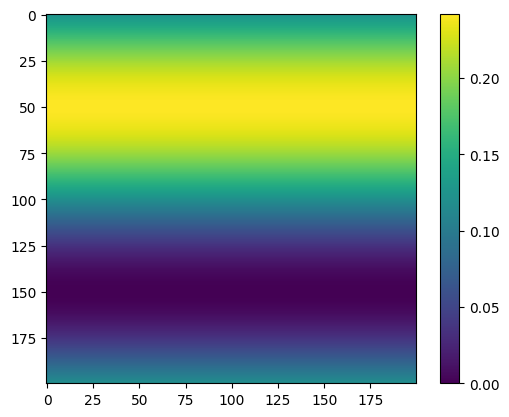

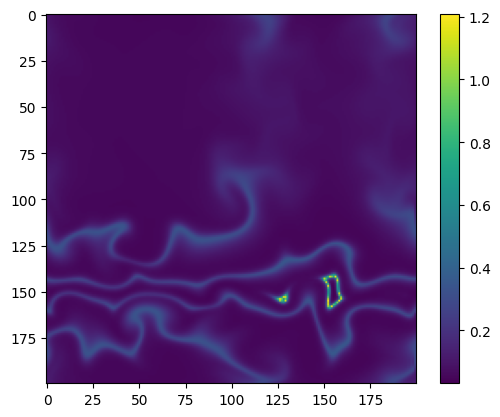

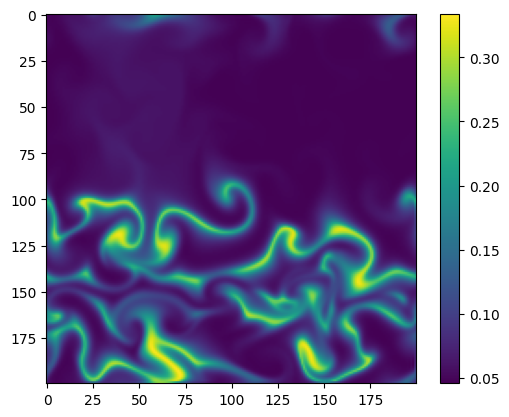

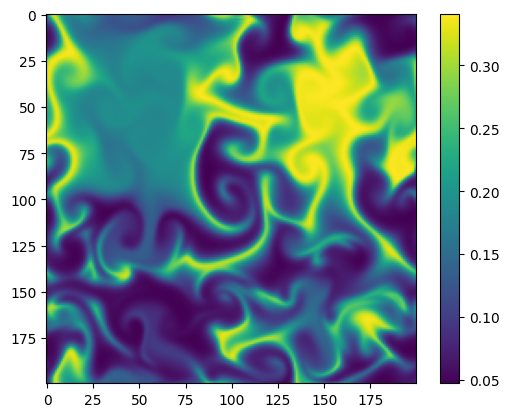

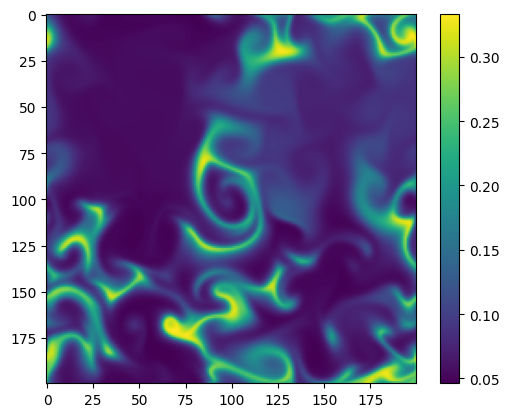

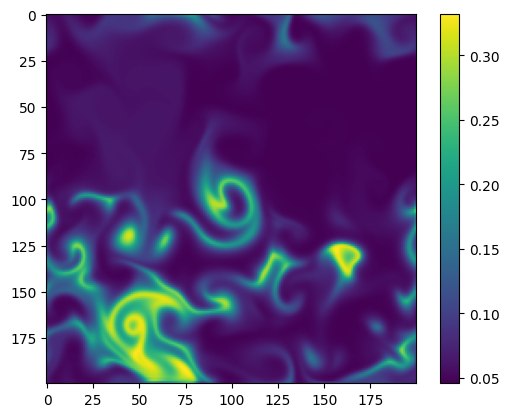

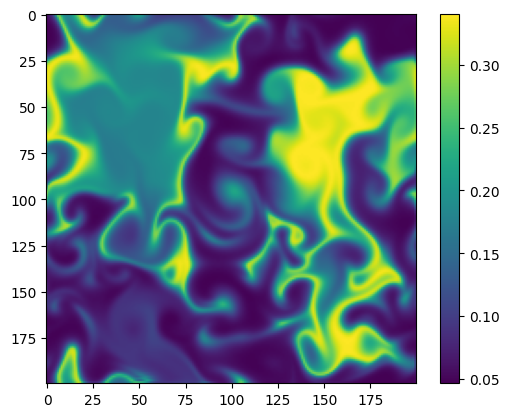

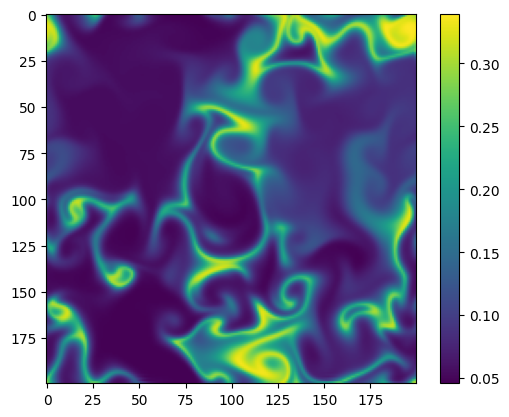

In [27]:
for i in range(8):
    plt.imshow(p_list[i*1000])
    plt.colorbar()
    plt.show()

In [28]:
# Now  for a compressible flow
new_x_centres = gen.uniform(0, 2 * L, size = 2)
new_y_centres = gen.uniform(0, 2 * L, size = 2)
new_sigma = [1,-1]

phi = stream(X, Y, new_x_centres, new_y_centres, r_0, new_sigma)

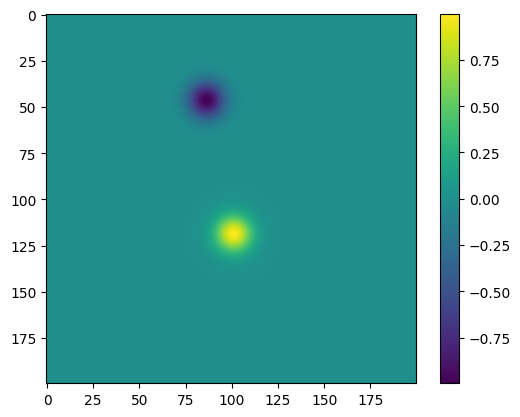

In [30]:
plt.imshow(phi)
plt.colorbar()
plt.show()

In [31]:
phi_y, phi_x = np.gradient(phi, dx)

In [63]:
beta = 10

In [64]:
u = (- (np.roll(psi,2,axis = 0) - 8 * np.roll(psi,1,axis = 0) + \
                    8 * np.roll(psi,-1,axis = 0) - np.roll(psi,-2,axis = 0)) / \
                    (12 * dx) + beta * phi_x) / np.sqrt(1 + beta**2)

v = ((np.roll(psi,2,axis = 1) - 8 * np.roll(psi,1,axis = 1) + \
                    8 * np.roll(psi,-1,axis = 1) - np.roll(psi,-2,axis = 1)) / \
                    (12 * dx) + beta * phi_y) / np.sqrt(1 + beta**2)

In [65]:
vel_mag = np.sqrt(u**2 + v**2)
max_vel = np.max(vel_mag)
s = nu_max / max_vel

In [66]:
u *= s
v *= s

In [67]:
t, n_list, p_list = solve_system_rk4(n, p, dt, T, u, v, d, i_n, a, m_n, f_p, dx)

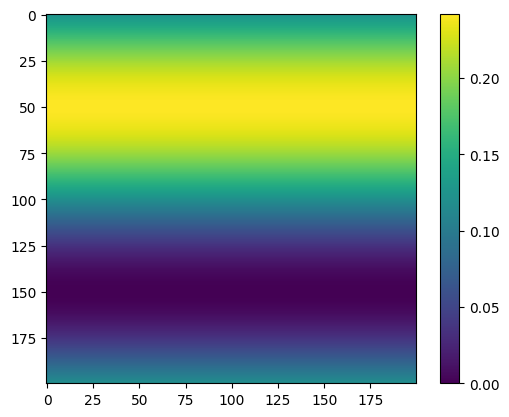

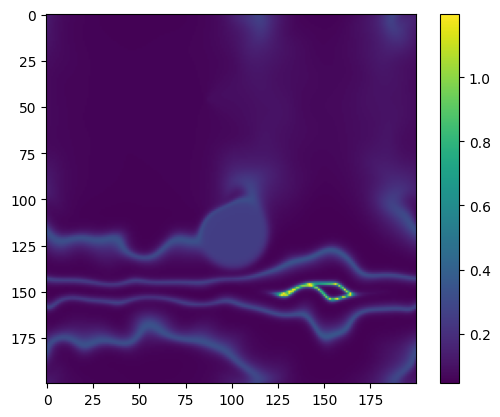

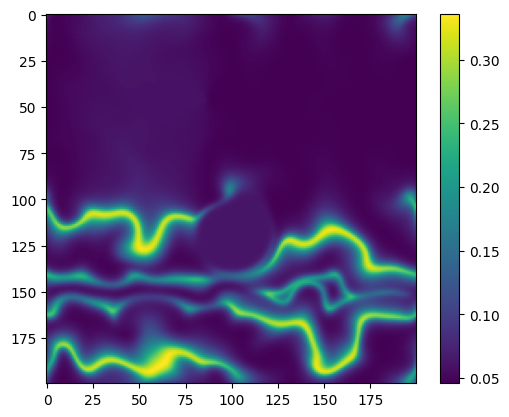

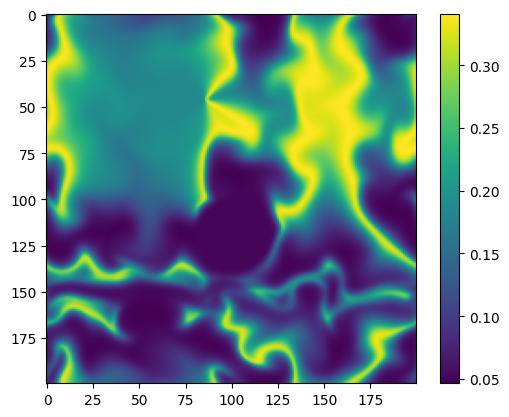

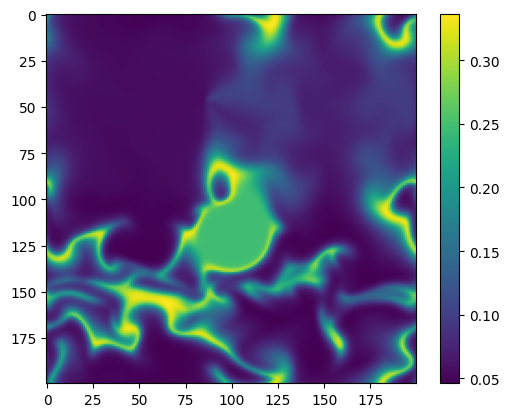

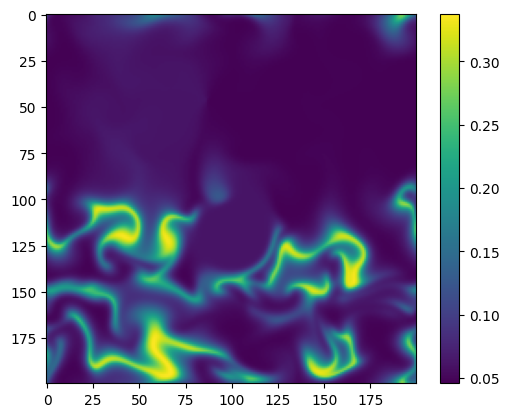

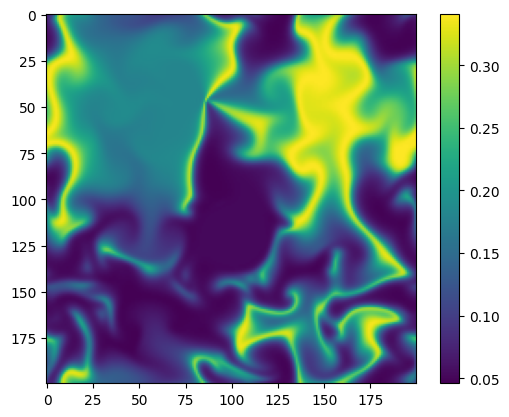

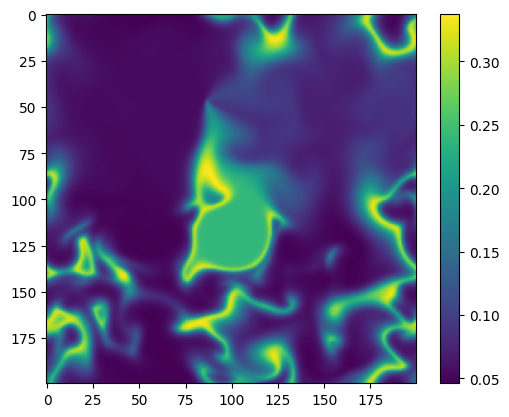

In [68]:
for i in range(8):
    plt.imshow(p_list[i*1000])
    plt.colorbar()
    plt.show()

In [69]:
def simplified_system(p, u, v, d, h, dt):

    return d * discrete_laplacian(p, h) - semi_lagrangian_tendency(p, h, dt, u, v, order = 3)

In [70]:
'''Function to solve the system of equations using RK4'''
def solve_simplified_system_rk4(p_0, dt, T, u, v, d,f_p, dx):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)
    
    p_list = [p_0]

    for _ in range(n_iter):

        prev_p = p_list[-1]

        k1_p = simplified_system(prev_p, u, v, d, dx, dt)

        
        k2_p = simplified_system(prev_p + k1_p*dt/2, u, v, d, dx, dt)
                
        
        k3_p = simplified_system(prev_p + k2_p*dt/2, u, v, d, dx, dt)

        
        k4_p = simplified_system(prev_p + k3_p*dt/2, u, v, d, dx, dt)

        new_p = prev_p + (k1_p + 2*k2_p + 2*k3_p + k4_p)*dt/6

        p_list.append(new_p)

    return t_interval, p_list

In [73]:
p = p_0 * np.ones_like(X)

In [74]:
t, p_list = solve_simplified_system_rk4(p,dt, T, u, v, d,f_p, dx)

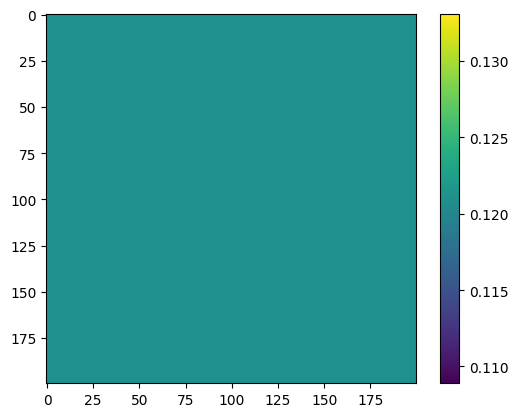

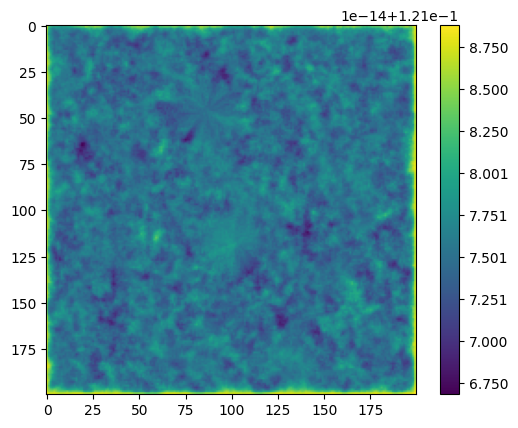

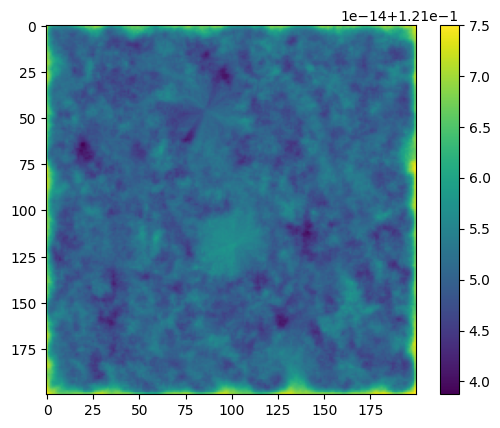

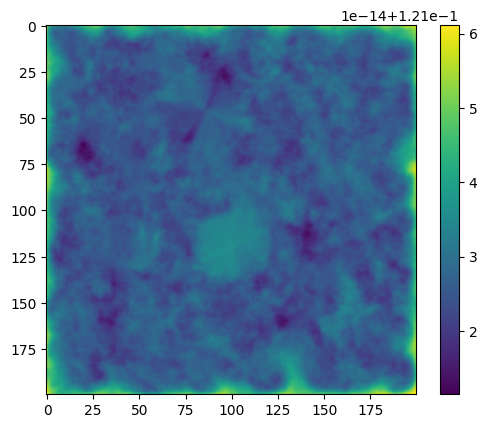

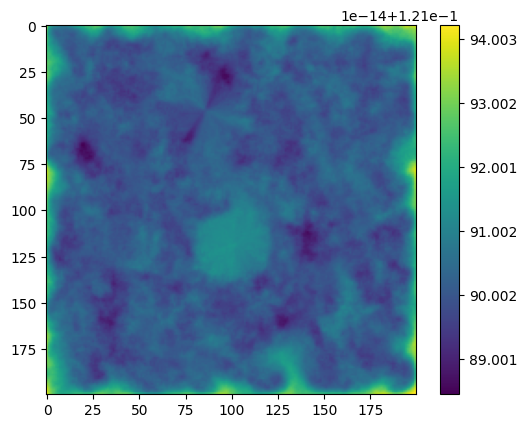

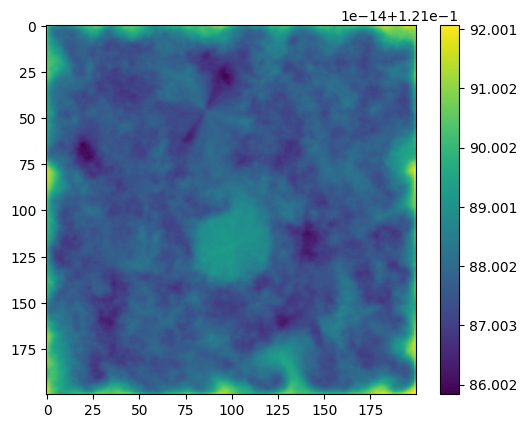

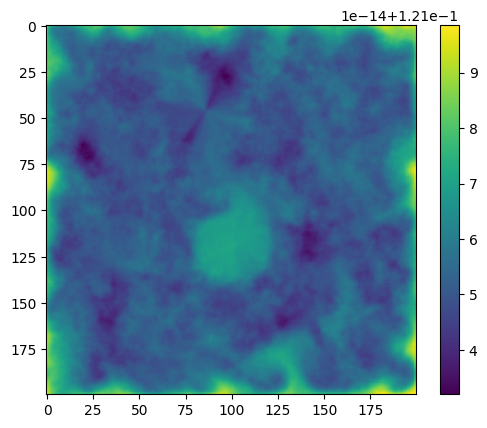

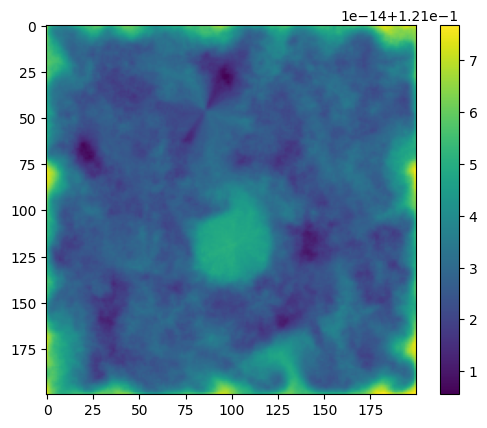

In [75]:
for i in range(8):
    plt.imshow(p_list[i*1000])
    plt.colorbar()
    plt.show()